# NuScenes Setup Guide

## 1. Nuscenes v1.0-mini Dataset Download

Use the following command to download the dataset:

```bash
curl --header 'Host: d36yt3mvayqw5m.cloudfront.net' --header 'User-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36' --header 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7' --header 'Accept-Language: en-US,en;q=0.9,zh-CN;q=0.8,zh;q=0.7' --header 'Referer: https://www.nuscenes.org/' 'https://d36yt3mvayqw5m.cloudfront.net/public/v1.0/v1.0-mini.tgz' -L -o 'v1.0-mini.tgz'
```

After downloading, unzip the file:

```bash
tar -xvzf v1.0-mini.tgz
```

---

## 2. Nuscenes Package Installation

Install the nuscenes-devkit package using pip:

```bash
pip install nuscenes-devkit
```

You can find the official repo here: [nuscenes-devkit](https://github.com/nutonomy/nuscenes-devkit)

---

## 3. Nuscenes Map Expansion (For Visualization)

Download the map expansion file:

```bash
curl --header 'Host: d36yt3mvayqw5m.cloudfront.net' --header 'User-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36' --header 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7' --header 'Accept-Language: en-US,en;q=0.9,zh-CN;q=0.8,zh;q=0.7' --header 'Referer: https://www.nuscenes.org/' 'https://d36yt3mvayqw5m.cloudfront.net/public/v1.0/nuScenes-map-expansion-v1.3.zip' -L -o 'nuScenes-map-expansion-v1.3.zip'
```

Unzip the file:

```bash
unzip nuScenes-map-expansion-v1.3.zip
```

Then copy the `/expansion` folder and paste it to your data directory in step 1:

You will have `YOUR_DATA_ROOT/nuscenes/maps/expansion/...`

---


\* If you find the dataset is incomplete, please check official download page: [link](https://www.nuscenes.org/nuscenes#download)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.map_expansion import arcline_path_utils
from nuscenes.map_expansion.bitmap import BitMap
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict


In [ ]:
import os

# Initialize nuScenes dataset
dataroot = os.path.expanduser('/home/aleenatron/Frames_AV_research')
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)

# Select a scene
scene_index = 6 #pedestriaan are crossing
scene = nusc.scene[scene_index]
first_sample_token = scene['first_sample_token']
sample = nusc.get('sample', first_sample_token)
ego_vehicle_start_time = sample['timestamp']

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.338 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [3]:
scene['description']

'Parking lot, bicycle rack, parked bicycles, bus, many peds, parked scooters, parked motorcycle'

## Get position coordinates and yaw of ego vehicle and all objects in world frame for the selected scene


In [4]:
# Get the correct map for the scene
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot='/home/aleenatron/Frames_AV_research', map_name=location)

# Store ego trajectory and object trajectories
ego_trajectory = []
ego_orientations = []
timestamps = []

object_trajectories = defaultdict(list)
object_orientations = defaultdict(list)
object_labels = {}
object_categories = {}  # Store category for each instance

# Function to convert quaternion to 2D yaw angle
def quaternion_to_yaw(quaternion):
    q = Quaternion(quaternion)
    yaw = np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))
    return yaw

# Track object instances separately
object_name_counter = defaultdict(int)

# Loop through all samples in the scene
sample_token = first_sample_token

while sample_token:
    sample = nusc.get('sample', sample_token)

    # Get timestamp (normalize between 0 and 1 for transparency)
    timestamps.append(sample['timestamp'])

    # Get ego_pose information
    sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])  # Using LiDAR for reference
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    ego_position = tuple(ego_pose['translation'][:2])  # X, Y position
    ego_yaw = quaternion_to_yaw(ego_pose['rotation'])  # Get orientation (yaw)

    ego_trajectory.append(ego_position)
    ego_orientations.append(ego_yaw)

    # Track all objects in the scene
    for ann_token in sample['anns']:
        ann_data = nusc.get('sample_annotation', ann_token)
        instance_token = ann_data['instance_token']
        object_position = tuple(ann_data['translation'][:2])  # Convert to tuple for uniqueness
        object_yaw = quaternion_to_yaw(ann_data['rotation'])  # Get orientation (yaw)

        # Get object category name
        category_name = ann_data['category_name']
        object_categories[instance_token] = category_name  # Store category

        # Differentiate identical objects with numbering (_1, _2, ...)
        if instance_token not in object_labels:
            object_name_counter[category_name] += 1
            unique_name = f"{category_name}_{object_name_counter[category_name]}"  # Append instance number
            object_labels[instance_token] = unique_name

        # Store object trajectory and orientation
        object_trajectories[instance_token].append(object_position)
        object_orientations[instance_token].append(object_yaw)

    # Move to the next sample
    sample_token = sample['next']

# Normalize timestamps for transparency (0 = oldest, 1 = newest)
timestamps = np.array(timestamps)
timestamps = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())  # Normalize between 0 and 1

# Convert ego trajectory to NumPy arrays for plotting
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)

## Get the most obvious moving objects (with their unique locations)

#number of unique (x, y) positions in the object’s trajectory
replace or augment it with smarter filters later (like spatial range + velocity)
❌ Misses subtle but important agents (e.g., slowly following ego, pedestrians waiting).

❌ Doesn’t prioritize agents near ego or in dangerous zones.

In [8]:
def select_most_moving_instances(object_trajectories, object_orientations, top_k=10):
    unique_location_counts = {}
    filtered_trajectories = {}
    filtered_orientations = {}

    for instance_token, trajectory in object_trajectories.items():
        unique_locs = OrderedDict()
        for i, loc in enumerate(trajectory):
            if loc not in unique_locs:
                unique_locs[loc] = object_orientations[instance_token][i]
        unique_location_counts[instance_token] = len(unique_locs)
        filtered_trajectories[instance_token] = list(unique_locs.keys())
        filtered_orientations[instance_token] = list(unique_locs.values())

    sorted_lengths = sorted(set(unique_location_counts.values()), reverse=True)
    if len(sorted_lengths) > top_k:
        threshold_length = sorted_lengths[top_k - 1]
        selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold_length}
    else:
        selected_instances = set(unique_location_counts.keys())
    
    return selected_instances, filtered_trajectories, filtered_orientations


In [6]:
selected_instances, filtered_trajectories, filtered_orientations = select_most_moving_instances(object_trajectories, object_orientations)


## Get the instance Frames with the Top-lidar's coordinate system (coordinate defined as: X-right, Y-forward)

In [9]:
for inst in selected_instances:
    print(f"{inst}: {object_labels[inst]}")


8fba9861aa6d4d14b78c90fbb5372fb2: vehicle.car_13
ec221beba32448e4a9865e920aeefed5: vehicle.car_32
55527032f0174fefa3b051a24707bf08: vehicle.car_19
fd4ce422e0db4ad3ab978a811ba04d3a: vehicle.car_26
29f69a7cb2c544c8a5ef26437a48e021: vehicle.car_30
ca5b3ca5aea745ee8fe12b0f74d77f8e: vehicle.car_2
a661e4cd1f644266a8307b4948082ae7: vehicle.car_35
8a26f7d33ff04b1a8c8679f8c4a7da91: vehicle.bus.rigid_1
0633f89a039a4e05bf60e53b57d1129d: vehicle.motorcycle_5
ba34f167479c43c69be921c9658a488c: vehicle.motorcycle_6
0cfdfb5bbe8a41268271e24f2edefb9c: vehicle.car_6
9ca01ff2a1b54d2eafaed768e58783ad: vehicle.car_31
293693af6bb54699a63dfb6d8db3504f: vehicle.car_27
856aeb4fa2024f1284c6290a44e9dec5: vehicle.car_21
41b3e689631a41e79d7c803f0765a693: vehicle.car_28
ec5241e32939433baeb2b3955920b28c: vehicle.car_15
6786acf4f6b644639d550c608785320f: vehicle.car_10
7e44b8c21c1a415c86f3bb874c4b01c0: vehicle.truck_2
11a08ff383a6451bbda6b9af56cfa6e2: vehicle.car_5


In [10]:
instance_id = "986c792f751041d38689019012a2e97b:"
print_debug = False

In [12]:
from collections import defaultdict, OrderedDict
import numpy as np
from pyquaternion import Quaternion
import os
from nuscenes.nuscenes import NuScenes


# Precompute ego vehicle positions
def compute_scene_ego_positions(nusc, scene_index):
    """Stores the ego vehicle's  (x, y) position in the world frame for each timestamp in seconds"""
    scene_ego_positions = {}
    scene = nusc.scene[scene_index]
    first_sample_token = scene['first_sample_token']
    first_sample = nusc.get('sample', first_sample_token)
    ego_vehicle_raw_start_time = first_sample['timestamp'] / 1e6

    sample_token = first_sample_token
    while sample_token:
        sample = nusc.get('sample', sample_token)
        timestamp = sample['timestamp'] / 1e6
        sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
        scene_ego_positions[timestamp] = tuple(ego_pose['translation'][:2])
        sample_token = sample['next']

    return scene_ego_positions, ego_vehicle_raw_start_time

class InstanceFrame:
    """ Class to store and process instance frame information from nuScenes dataset. """
    
    def __init__(self, nusc, instance_token, scene_index, scene_ego_positions, ego_vehicle_raw_start_time, timestamps):
        """
        Initializes an InstanceFrame object and extracts relevant data.

        Args:
            nusc: NuScenes database instance.
            instance_token: The token of the instance to extract.
            scene_index: The index of the scene in nuScenes dataset.
            scene_ego_positions: Precomputed ego vehicle positions for this scene.
            ego_vehicle_raw_start_time: The raw start timestamp of the ego vehicle (in seconds).
        """
        self.nusc = nusc
        self.instance_token = instance_token
        self.scene_index = scene_index
        self.scene_ego_positions = scene_ego_positions
        self.ego_vehicle_raw_start_time = ego_vehicle_raw_start_time

        # Core attributes
        self.category_name = None
        self.instance_name = None
        self.start_time = None
        self.end_time = None
        self.duration = None
        self.raw_start_time = None
        self.raw_end_time = None
        self.locations = []
        self.orientations = []
        self.sample_tokens = []
        self.scene_token = None
        self.timestamps = timestamps

        # Extract information
        self._extract_instance_data()
        self._normalize_times()
        self.intent = self._predict_intent()

    def _extract_instance_data(self):
        """ Extract structured Frame representation for the instance in nuScenes.
    Inputs:
        - self.instance_token: token representing a unique object instance (e.g., a specific car).
        - self.nusc: NuScenes database instance, used to query samples and annotations.
        - self.scene_index: the index of the scene the instance belongs to.
        - self.ego_vehicle_raw_start_time: timestamp (in seconds) of the first ego frame in this scene.
        - self.scene_ego_positions: dictionary mapping timestamps to ego vehicle (x, y) positions.

    Outputs:
        - self.locations: list of [x, y] positions of the object in the LiDAR (ego-relative) frame.
        - self.orientations: list of yaw angles (radians) of the object in the LiDAR frame.
        - self.sample_tokens: list of frame tokens in which this object appears.
        - self.category_name: the class/type of the object (e.g., 'vehicle.car', 'human.pedestrian').
        - self.start_time, self.end_time: normalized start and end timestamps of the object’s trajectory.
        - self.raw_start_time, self.raw_end_time: raw (absolute) start/end timestamps.
        - self.scene_token: the unique scene token for grouping multiple object tracks together.
        - self.duration: total time the object was tracked.
        """

        instance = self.nusc.get('instance', self.instance_token)
        first_ann_token = instance['first_annotation_token']
        
        ann = self.nusc.get('sample_annotation', first_ann_token)
        self.category_name = ann['category_name']

        while ann:
            sample = self.nusc.get('sample', ann['sample_token'])
            timestamp = sample['timestamp'] / 1e6  # Convert to seconds
            

            if self.start_time is None:
                self.start_time = timestamp
                self.raw_start_time = timestamp
                self.scene_token = sample["scene_token"]

            self.end_time = timestamp
            self.raw_end_time = timestamp

            # Transform annotation from global frame to LiDAR frame
            lidar_translation, lidar_rotation = self._get_lidar_pose(sample['data']['LIDAR_TOP'])
            obj_translation = np.array(ann["translation"])
            obj_rotation = Quaternion(ann["rotation"])

            transformed_translation, transformed_yaw = self._transform_global_to_lidar(
                obj_translation, obj_rotation, lidar_translation, lidar_rotation
            )

            self.locations.append(transformed_translation[:2])  # X, Y in LiDAR frame
            self.orientations.append(transformed_yaw)  # Yaw in LiDAR frame
            

            self.sample_tokens.append(ann["sample_token"])

            if ann["next"]:
                ann = self.nusc.get("sample_annotation", ann["next"])
            else:
                break

        self.duration = self.end_time - self.start_time

    def _normalize_times(self):
        """ Normalize start and end times relative to the ego vehicle's first timestamp in the scene. """
        self.start_time -= self.ego_vehicle_raw_start_time
        self.end_time -= self.ego_vehicle_raw_start_time

    def _get_lidar_pose(self, lidar_token):
        """ Retrieve the LiDAR position and rotation in world frame from ego pose. """
        lidar_data = self.nusc.get('sample_data', lidar_token)
        ego_pose = self.nusc.get('ego_pose', lidar_data['ego_pose_token'])
        return np.array(ego_pose['translation']), Quaternion(ego_pose['rotation'])

    def _transform_global_to_lidar(self, obj_translation, obj_rotation, lidar_translation, lidar_rotation):
        """
        Transform object position and orientation from global frame to the LiDAR frame.
        """
    

    
        # Step 1: Translate to LiDAR's origin
        relative_translation = obj_translation - lidar_translation

    
        # Step 2: Rotate using inverse of LiDAR rotation
        transformed_translation = lidar_rotation.inverse.rotate(relative_translation)
        
        # **Fix the Axis Swapping Issue**
        transformed_translation = np.array([-transformed_translation[1], transformed_translation[0], transformed_translation[2]])
        

        # Step 3: Convert rotation to LiDAR's frame

        transformed_rotation = lidar_rotation.inverse * obj_rotation
        transformed_yaw = np.arctan2(
            2.0 * (transformed_rotation.w * transformed_rotation.z + transformed_rotation.x * transformed_rotation.y),
            1.0 - 2.0 * (transformed_rotation.y**2 + transformed_rotation.z**2)
        )
    

        # Choose whether debug with print
        if print_debug:
            print(f" LiDAR Position: {obj_rotation}")           
            print(f" Global Position: {obj_translation}")
            print(f" LiDAR Position: {lidar_translation}")
            print(f" Relative Position (before rotation): {relative_translation}")
            print(f"✅ Fixed Transformed Position (LiDAR Frame): {transformed_translation}")
            print(f" Original Rotation (Quaternion): {obj_rotation}")
            print(f"✅ Transformed Yaw (LiDAR Frame): {np.degrees(transformed_yaw)} degrees")
    
        return transformed_translation, transformed_yaw


    def _classify_orientation(self, yaw_rad):
        """ Classify the relative orientation in LiDAR frame. """
        yaw_deg = np.degrees(yaw_rad) % 360
        if yaw_deg > 180:
            yaw_deg -= 360  # Normalize to [-180, 180]

        if abs(yaw_deg) < 45:
            return "facing same direction"
        elif abs(yaw_deg - 180) < 45 or abs(yaw_deg + 180) < 45:
            return "facing opposite direction"
        elif 45 <= yaw_deg <= 135:
            return "facing leftward (perpendicular)"
        elif -135 <= yaw_deg <= -45:
            return "facing rightward (perpendicular)"
        else:
            return "heading unclear"
    
    # def _predict_intent(self):
    #     # If not enough points, skip
    #     if len(self.locations) < 3:
    #         print("[EXIT] Too few locations")
    #         return "none"

    #     # === 1. Compute movement ===
    #     displacements = np.diff(self.locations, axis=0)  # (N-1, 2): Δx, Δy between frames
    #     dt = self.duration / len(displacements)  # Average timestep
    #     velocities = displacements / dt  # (N-1, 2): Instantaneous velocities
    #     total_disp = np.sum(displacements, axis=0)  # Total net displacement
    #     lateral_disp, forward_disp = total_disp[0], total_disp[1]  # LiDAR: x=lateral, y=forward

    #     print(f"[MOTION] Lateral: {lateral_disp:.2f}, Forward: {forward_disp:.2f}, Duration: {self.duration:.2f}s")

    #     # === 2. Orientation features ===
    #     yaw_deltas = np.diff(self.orientations)
    #     avg_yaw_rate = np.mean(np.abs(yaw_deltas))  # Avg turning speed in radians
    #     yaw_agent = self.orientations[-1]  # Last orientation of agent
    #     yaw_ego = 0  # Ego always faces +Y in LiDAR frame
    #     heading_diff = abs((yaw_agent - yaw_ego + np.pi) % (2 * np.pi) - np.pi)  # Relative angle

    #     print(f"[YAW] avg_yaw_rate: {avg_yaw_rate:.2f}, heading_diff: {np.degrees(heading_diff):.1f}°")

    #     # === 3. Use final relative position ===
    #     x, y = self.locations[-1]  # Final LiDAR-frame position
    #     # if not (-10 <= x <= 10 and -20 <= y <= 50):
    #     #     print(f"[SKIP] Out of LiDAR visible area: x={x:.2f}, y={y:.2f}")
    #     #     return "none"

    #     # === 4. Get ego vehicle positions ===
    #     ego_positions_raw = []
    #     valid_times = list(self.scene_ego_positions.keys())

    #     for t in self.timestamps:
    #         closest = min(valid_times, key=lambda x: abs(x - t))
    #         if abs(closest - t) < 1e5:  # allow matching within 0.1 seconds
    #             ego_positions_raw.append(self.scene_ego_positions[closest])
    #         else:
    #             ego_positions_raw.append(None)


    #             # DEBUG: Print how many ego positions were matched
    #     print(f"[EGO MATCHING] Found {len(valid_idxs)} valid ego positions out of {len(self.locations)}")
    #     print(f"[EGO MATCHING] Valid index list: {valid_idxs}")

    #     if len(valid_idxs) < 2:
    #         print(f"[EXIT] {self.instance_token} — too few valid ego positions, skipping intent")
    #         return "none"

    #     # === 5. Compute ego motion ===
    #     ego_positions = np.array([ego_positions_raw[i] for i in valid_idxs])
    #     ego_velocities = np.diff(ego_positions, axis=0) / dt
    #     ego_moving = np.mean(np.linalg.norm(ego_velocities, axis=1)) > 0.5  # threshold: 0.5 m/s

    #     print(f"[EGO] moving: {ego_moving}, samples: {len(ego_positions)}")

    #     # === 6. Relative velocity ===
    #     if ego_moving:
    #         agent_vel = velocities[valid_idxs[:-1]]
    #         ego_vel = ego_velocities
    #         rel_velocities = agent_vel - ego_vel
    #     else:
    #         rel_velocities = velocities

    #     mean_rel_vel = np.mean(rel_velocities, axis=0)  # mean_rel_vel[0]=lateral, [1]=forward

    #     print(f"[REL VEL] lateral={mean_rel_vel[0]:.2f}, forward={mean_rel_vel[1]:.2f}")

    #     # === 7. Decision tree ===
    #     if self.category_name.startswith("vehicle"):
    #         print(f"[VEHICLE] → instance: {self.instance_token}")

    #         # Condition 1: Turning
    #         if avg_yaw_rate > 0.15 and abs(forward_disp) > 2.0:
    #             print(" → Intent: turning")
    #             return "turning"

    #         # Condition 2: Lane change
    #         if abs(lateral_disp) > 1.5 and abs(lateral_disp) > 0.7 * abs(forward_disp):
    #             print(" → Intent: lane change")
    #             return "lane change"

    #         # Condition 3: Following (close and slightly faster than ego)
    #         if y < 10 and mean_rel_vel[1] > 0.2:
    #             print(" → Intent: following")
    #             return "following"

    #         # Condition 4: Co-moving (parallel)
    #         if y < 10 and abs(mean_rel_vel[1]) < 0.2:
    #             print(" → Intent: co-moving")
    #             return "co-moving"

    #     elif self.category_name.startswith("human"):
    #         speed = np.linalg.norm(mean_rel_vel)
    #         print(f"[HUMAN] speed: {speed:.2f}, forward_disp: {forward_disp:.2f}")

    #         # Condition 1: Waiting to cross
    #         if speed < 0.4:
    #             print(" → Intent: waiting to cross")
    #             return "waiting to cross"

    #         # Condition 2: Actively crossing
    #         if forward_disp > 1.5 or mean_rel_vel[1] > 0.5:
    #             print(" → Intent: crossing")
    #             return "crossing"

    #     # Default fallback
    #     print(" → Intent: none")
    #     return "none"
    def _predict_intent(self):
        if len(self.locations) < 3:
            print("[EXIT] Too few locations")
            return "none"

        # 1. Motion
        displacements = np.diff(self.locations, axis=0)
        dt = self.duration / len(displacements)
        velocities = displacements / dt
        total_disp = np.sum(displacements, axis=0)
        lateral_disp, forward_disp = total_disp[0], total_disp[1]
        print(f"[MOTION] Lateral: {lateral_disp:.2f}, Forward: {forward_disp:.2f}, Duration: {self.duration:.2f}s")

        # 2. Orientation
        yaw_deltas = np.diff(self.orientations)
        avg_yaw_rate = np.mean(np.abs(yaw_deltas))
        yaw_agent = self.orientations[-1]
        heading_diff = abs((yaw_agent + np.pi) % (2 * np.pi) - np.pi)
        print(f"[YAW] avg_yaw_rate: {avg_yaw_rate:.2f}, heading_diff: {np.degrees(heading_diff):.1f}°")

        # 3. Ego-relative matching
        ego_positions_raw = []
        valid_idxs = []
        available_times = list(self.scene_ego_positions.keys())
        for i, t in enumerate(self.timestamps):
            closest = min(available_times, key=lambda x: abs(x - t))
            if abs(closest - t) < 0.1:  # within 0.1 sec
                ego_positions_raw.append(self.scene_ego_positions[closest])
                valid_idxs.append(i)
            else:
                ego_positions_raw.append(None)

        print(f"[EGO MATCHING] Found {len(valid_idxs)} valid ego positions out of {len(self.locations)}")
        print(f"[EGO MATCHING] Valid index list: {valid_idxs}")
        if len(valid_idxs) < 2:
            return "none"

        
        return "crossing" if forward_disp > 3 else "stationary"


             
    def describe_movement(self):
        """
        A detailed scenario-based & dominant-direction movement description
        in LiDAR frame (x=right, y=up), considering the **entire trajectory**.
    
        Key features:
        - Describes movement trends over time.
        - Separates Left/Right and Forward/Backward positioning (no center state).
        - Tracks relative positioning with respect to the ego vehicle.
        - Detects crossing events (left↔right, behind↔ahead).
        - Computes movement dominance dynamically.
        - Reports mean and minimum distance to the ego vehicle.
    
        The 'one region' logic: explicitly says "always left/right" or "always behind/ahead"
        if applicable.



        TODO: 
              1. We take the relative distances as the trajectory distance (which might not be the same as the actual path length, according to the ego vehicle).
        """
    
        if len(self.locations) < 2:
            return "Not enough data to describe movement."
    
        distances_to_ego = [np.linalg.norm(loc) for loc in self.locations]
        mean_distance = np.mean(distances_to_ego)
        min_distance = np.min(distances_to_ego)

        movement_segments = []
        heading_segments = []
        segment_changes_lr = []
        segment_changes_fb = []
        relative_lr = []
        relative_fb = []
        total_distance = 0

        prev_x, prev_y = self.locations[0]

        for i in range(1, len(self.locations)):
            cur_x, cur_y = self.locations[i]
            dx, dy = cur_x - prev_x, cur_y - prev_y
            distance = np.hypot(dx, dy)
            total_distance += distance

            # --- Movement direction ---
            if distance < 0.5:
                move_desc = "had minor movement"
            else:
                abs_dx, abs_dy = abs(dx), abs(dy)
                ratio = abs_dx / abs_dy if abs_dy > 1e-6 else float('inf')
                if ratio > 1.5:
                    move_desc = "moved dominantly right" if dx > 0 else "moved dominantly left"
                elif ratio < 0.66:
                    move_desc = "moved dominantly forward" if dy > 0 else "moved dominantly backward"
                else:
                    move_desc = "moved diagonally"
            movement_segments.append(move_desc)

            # --- Orientation status ---
            heading_segments.append(self._classify_orientation(self.orientations[i]))

            # --- Relative lateral / longitudinal position ---
            cur_lr = "left" if cur_x < 0 else "right"
            cur_fb = "behind" if cur_y < 0 else "ahead"

            if i > 1:
                prev_lr, prev_fb = relative_lr[-1], relative_fb[-1]
                if prev_lr != cur_lr:
                    segment_changes_lr.append(f"crossed from {prev_lr} to {cur_lr}")
                if prev_fb != cur_fb:
                    segment_changes_fb.append(f"crossed from {prev_fb} to {cur_fb}")

            relative_lr.append(cur_lr)
            relative_fb.append(cur_fb)

            prev_x, prev_y = cur_x, cur_y

        movement_trend = ", then ".join(dict.fromkeys(movement_segments))
        heading_trend = ", then ".join(dict.fromkeys(heading_segments))

        # Position summaries
        lr_summary = (
            f"always {relative_lr[0]}" if len(set(relative_lr)) == 1 else
            ", ".join(dict.fromkeys(segment_changes_lr)) if segment_changes_lr else
            "exhibited partial left/right shifts"
        )
        fb_summary = (
            f"always {relative_fb[0]}" if len(set(relative_fb)) == 1 else
            ", ".join(dict.fromkeys(segment_changes_fb)) if segment_changes_fb else
            "exhibited partial forward/back shifts"
        )

        return (
            f"A {self.category_name} {movement_trend}. "
            f"Relative to the ego vehicle, it was {lr_summary} laterally "
            f"and {fb_summary} longitudinally. "
            f"It covered a total distance of approximately {total_distance:.2f}m over {self.duration:.2f}s. "
            f"Mean distance: {mean_distance:.2f}m, closest approach: {min_distance:.2f}m. "
            f"Its orientation over time was: {heading_trend}."
            f"\nLikely intent: {self.intent}."
        )
        
    def to_dict(self):
        """ Converts the instance frame object to a dictionary for easy usage. """
        return {
            "instance_token": self.instance_token,
            "category_name": self.category_name,
            "instance_name": self.instance_name,
            "raw_start_time": self.raw_start_time,
            "raw_end_time": self.raw_end_time,
            "ego_vehicle_raw_start_time": self.ego_vehicle_raw_start_time,
            "start_time": self.start_time,
            "end_time": self.end_time,
            "duration": self.duration,
            "locations": self.locations,
            "orientations": self.orientations,
            "sample_tokens": self.sample_tokens,
            "scene_token": self.scene_token,
            "description": self.describe_movement()
        }

# Example usage:
# scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
# instance_frame = InstanceFrame(nusc, instance_id, 2, scene_ego_positions, ego_vehicle_raw_start_time)#888521a8b57f46258e81a89bf062278b
# print(instance_frame.to_dict())

## Get the description for all filtered instances

In [13]:
scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 9)
instance_descriptions = []
predicted_intents = {}

for instance_id in selected_instances:
    instance_frame = InstanceFrame(nusc, instance_id, 9, scene_ego_positions, ego_vehicle_raw_start_time, timestamps=timestamps.tolist())
    
    # Save the intent
    predicted_intents[instance_id] = instance_frame.intent

    # Save the description
    print('instance_id:', instance_id)
    print(instance_frame.describe_movement())
    print("\n")
    instance_descriptions.append(instance_frame.describe_movement())

[MOTION] Lateral: -50.79, Forward: -61.70, Duration: 17.40s
[YAW] avg_yaw_rate: 0.26, heading_diff: 103.6°
[EGO MATCHING] Found 0 valid ego positions out of 36
[EGO MATCHING] Valid index list: []
instance_id: 8fba9861aa6d4d14b78c90fbb5372fb2
A vehicle.car moved diagonally, then moved dominantly left, then moved dominantly backward. Relative to the ego vehicle, it was crossed from right to left laterally and crossed from ahead to behind longitudinally. It covered a total distance of approximately 110.61m over 17.40s. Mean distance: 24.47m, closest approach: 7.12m. Its orientation over time was: facing leftward (perpendicular), then facing opposite direction, then facing rightward (perpendicular).
Likely intent: none.


[MOTION] Lateral: -31.92, Forward: -12.85, Duration: 15.50s
[YAW] avg_yaw_rate: 0.08, heading_diff: 46.1°
[EGO MATCHING] Found 0 valid ego positions out of 32
[EGO MATCHING] Valid index list: []
instance_id: ec221beba32448e4a9865e920aeefed5
A vehicle.car moved dominantly 

In [14]:
scene_ego_positions

{1542800987.947699: (1321.390767646126, 903.7547711424545),
 1542800988.448155: (1321.3902406441357, 903.7549653084047),
 1542800988.948006: (1321.3899865263702, 903.7552613750836),
 1542800989.447876: (1321.389884265855, 903.7555923020861),
 1542800989.947775: (1321.3897397517453, 903.7558398479971),
 1542800990.447665: (1321.389703450702, 903.7561104622332),
 1542800990.947514: (1321.3895744960623, 903.7562794388518),
 1542800991.448017: (1321.389497347068, 903.7564473471818),
 1542800991.947811: (1321.389546034655, 903.756666382795),
 1542800992.447751: (1321.3900926964782, 903.7571833802997),
 1542800992.897804: (1321.397282300359, 903.7619872675373),
 1542800993.397691: (1321.349381757199, 903.732461696289),
 1542800993.897003: (1321.3319707051842, 903.7244419713054),
 1542800994.396889: (1321.3309098600103, 903.7264533775212),
 1542800994.896757: (1321.3301728342717, 903.7282877151674),
 1542800995.397176: (1321.329462527197, 903.7298227825347),
 1542800995.898163: (1321.32986809

In [15]:
predicted_intents

{'8fba9861aa6d4d14b78c90fbb5372fb2': 'none',
 'ec221beba32448e4a9865e920aeefed5': 'none',
 '55527032f0174fefa3b051a24707bf08': 'none',
 'fd4ce422e0db4ad3ab978a811ba04d3a': 'none',
 '29f69a7cb2c544c8a5ef26437a48e021': 'none',
 'ca5b3ca5aea745ee8fe12b0f74d77f8e': 'none',
 'a661e4cd1f644266a8307b4948082ae7': 'none',
 '8a26f7d33ff04b1a8c8679f8c4a7da91': 'none',
 '0633f89a039a4e05bf60e53b57d1129d': 'none',
 'ba34f167479c43c69be921c9658a488c': 'none',
 '0cfdfb5bbe8a41268271e24f2edefb9c': 'none',
 '9ca01ff2a1b54d2eafaed768e58783ad': 'none',
 '293693af6bb54699a63dfb6d8db3504f': 'none',
 '856aeb4fa2024f1284c6290a44e9dec5': 'none',
 '41b3e689631a41e79d7c803f0765a693': 'none',
 'ec5241e32939433baeb2b3955920b28c': 'none',
 '6786acf4f6b644639d550c608785320f': 'none',
 '7e44b8c21c1a415c86f3bb874c4b01c0': 'none',
 '11a08ff383a6451bbda6b9af56cfa6e2': 'none'}

## Try to get the overall description of a scene (concatenate all instances' descriptions)

In [16]:
overall_description = ''.join(instance_descriptions)

In [17]:
overall_description

'A vehicle.car moved diagonally, then moved dominantly left, then moved dominantly backward. Relative to the ego vehicle, it was crossed from right to left laterally and crossed from ahead to behind longitudinally. It covered a total distance of approximately 110.61m over 17.40s. Mean distance: 24.47m, closest approach: 7.12m. Its orientation over time was: facing leftward (perpendicular), then facing opposite direction, then facing rightward (perpendicular).\nLikely intent: none.A vehicle.car moved dominantly backward, then moved dominantly right, then moved dominantly forward, then moved diagonally, then moved dominantly left. Relative to the ego vehicle, it was always right laterally and crossed from behind to ahead, crossed from ahead to behind longitudinally. It covered a total distance of approximately 132.44m over 15.50s. Mean distance: 40.90m, closest approach: 25.86m. Its orientation over time was: facing same direction, then facing leftward (perpendicular).\nLikely intent: no

### You should set up OPENAI_API_KEY before calling the openai models

In [ ]:
from openai import OpenAI
client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    input=(f"Write a one-sentence summary about the scene, identify specific important objects in autonomous driving scenarios:{overall_description}.")
)

print(response.output_text)
# from openai import OpenAI
# client = OpenAI()

# response = client.responses.create(
#     model="gpt-4o-mini",
#     input=(
#         "Summarize the following frame-based object movement descriptions in a single sentence. "
#         "Do not omit any specific object intent such as 'crossing', 'turning', or 'lane change'. "
#         "Keep these terms intact in the final output. Here is the input:\n"
#         f"{overall_description}"
#     )
# )

# print(response.output_text)


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
# # Provide a template for the summary (use the first scene description as a reference, but please do not use the current scene description):

# from openai import OpenAI
# client = OpenAI()

# response = client.responses.create(
#     model="gpt-4o-mini",
#     input=f"Write a one-sentence summary about the scene, identify specific important objects in autonomous driving scenarios keeping their intent:{overall_description}. You should output the summary like {nusc.scene[1]['description'] }. "
# )

# print(response.output_text)

Many peds left, move diagonally, crossing ego vehicle, backward cars right, long bus right, turning hedge.


In [21]:
with open("scene9_after_intent.txt", "w") as f:
    f.write(response.output_text)

In [22]:
# The ground truth for the scene description from the nuScenes dataset:
nusc.scene[9]['description']

'Night, peds in sidewalk, peds cross crosswalk, scooter, PMD, difficult lighting'

## Validate the Frame description of an instance with its birds-eye-view visualization

Check an id "instance_id = '2e19253f3bac458191cf64ff2b22ba2b'". A bus turnning left (from birds-eye view)

In [23]:
instance_id = '48d58b69b40149aeb2e64aa4b1a9192f'

In [24]:
instance_frame = InstanceFrame(nusc, instance_id, 9, scene_ego_positions, ego_vehicle_raw_start_time)
print('instance_id:', instance_id)
print(instance_frame.describe_movement())

instance_id: 48d58b69b40149aeb2e64aa4b1a9192f
A human.pedestrian.adult moved dominantly backward, then moved diagonally, then moved dominantly left. Relative to the ego vehicle, it was crossed from right to left laterally and crossed from ahead to behind longitudinally. It covered a total distance of approximately 100.41m over 14.55s. Mean distance: 33.57m, closest approach: 22.85m. Its orientation over time was: facing same direction, then facing rightward (perpendicular).
Likely intent: none.


In [25]:
print(instance_frame.intent)


none


### Visualize the selected instance and put it on the map

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.634 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


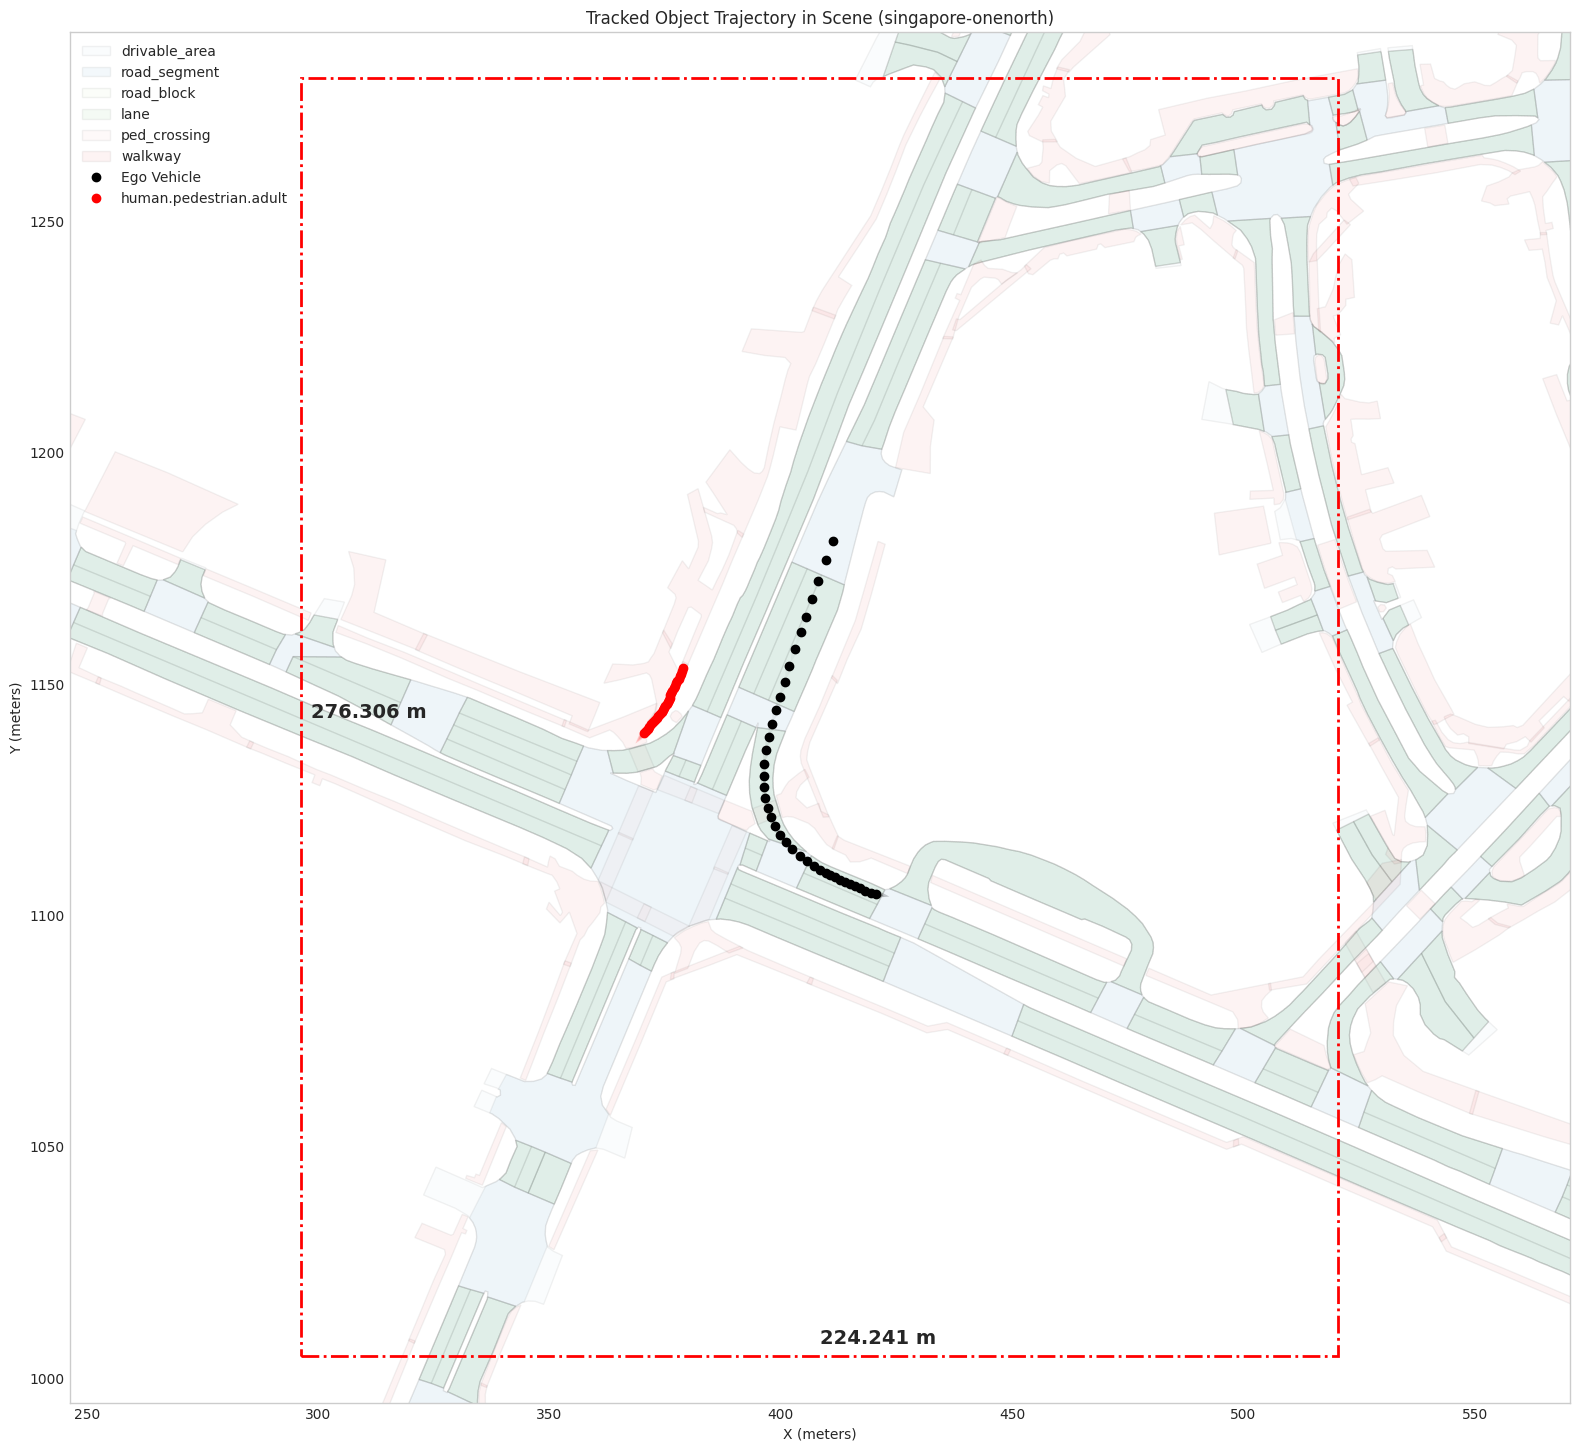

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# Toggle to control arrow display (set to False to hide arrows)
show_arrows = True

# Step 1: Load nuScenes dataset
dataroot = os.path.expanduser('/home/aleenatron/Frames_AV_research')  # Adjust this path as needed
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)

# Step 2: Define the scene and the instance you want to visualize
scene_index = 0  # Adjust this to your scene index
instance_token = instance_id  # Replace with the actual instance token

# Step 3: Load scene and map
scene = nusc.scene[scene_index]
first_sample_token = scene['first_sample_token']
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot=dataroot, map_name=location)

# Step 4: Function to convert quaternion to yaw
def quaternion_to_yaw(quaternion):
    q = Quaternion(quaternion)
    return np.arctan2(2.0*(q.w*q.z + q.x*q.y), 1.0 - 2.0*(q.y*q.y + q.z*q.z))

# Step 5: Store trajectories
ego_trajectory = []
ego_orientations = []
timestamps = []
object_trajectory = []
object_orientations = []

# Step 6: Loop through all samples in the scene
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)
    timestamps.append(sample['timestamp'])
    
    # Get ego vehicle pose using LIDAR_TOP
    sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    ego_trajectory.append(tuple(ego_pose['translation'][:2]))  # X, Y position
    ego_orientations.append(quaternion_to_yaw(ego_pose['rotation']))
    
    # Process all objects in the scene; only consider the specified instance
    for ann_token in sample['anns']:
        ann_data = nusc.get('sample_annotation', ann_token)
        if ann_data['instance_token'] == instance_token:
            object_trajectory.append(tuple(ann_data['translation'][:2]))
            object_orientations.append(quaternion_to_yaw(ann_data['rotation']))
    
    sample_token = sample['next']

# Step 7: Normalize timestamps
timestamps = np.array(timestamps)
timestamps = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())

# Step 8: Convert lists to NumPy arrays
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)
object_trajectory = np.array(object_trajectory)
object_orientations = np.array(object_orientations)

# Step 9: Determine map bounds
x_min, y_min = np.min(ego_trajectory, axis=0) - 100
x_max, y_max = np.max(ego_trajectory, axis=0) + 100
map_bounds = (x_min, y_min, x_max, y_max)

# Step 10: Define map layers
layer_names = ["drivable_area", "road_segment", "road_block", "lane", "ped_crossing", "walkway"]

# Step 11: Render the map patch with 50% transparency
fig, ax = nusc_map.render_map_patch(map_bounds, layer_names, alpha=0.05)
ax.set_aspect('equal')

# Step 12: Plot ego vehicle trajectory in black and add arrows (if enabled)
ax.plot(ego_trajectory[:, 0], ego_trajectory[:, 1], 'o', color="black", label="Ego Vehicle")
if show_arrows:
    for i in range(len(ego_trajectory)):
        alpha = timestamps[i]
        dx = 3 * np.cos(ego_orientations[i])
        dy = 3 * np.sin(ego_orientations[i])
        ax.quiver(ego_trajectory[i, 0], ego_trajectory[i, 1], dx, dy,
                  angles='xy', scale_units='xy', scale=1, color=(0,0,0,0.2*alpha))

# Step 13: Plot object trajectory in red and add arrows (if enabled)
#object_trajectory = np.array(object_trajectory)
ax.plot(object_trajectory[:, 0], object_trajectory[:, 1], 'o', color="red", label=f"{instance_frame.category_name}")
if show_arrows:
    for i in range(len(object_trajectory)):
        alpha = timestamps[i]
        dx = 3 * np.cos(object_orientations[i])
        dy = 3 * np.sin(object_orientations[i])
        ax.quiver(object_trajectory[i, 0], object_trajectory[i, 1], dx, dy,
                  angles='xy', scale_units='xy', scale=1, color=(1,0,0,0.2*alpha))

# Step 14: Labels and legend
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Tracked Object Trajectory in Scene ({location})")
plt.legend()
plt.grid()
plt.show()

/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


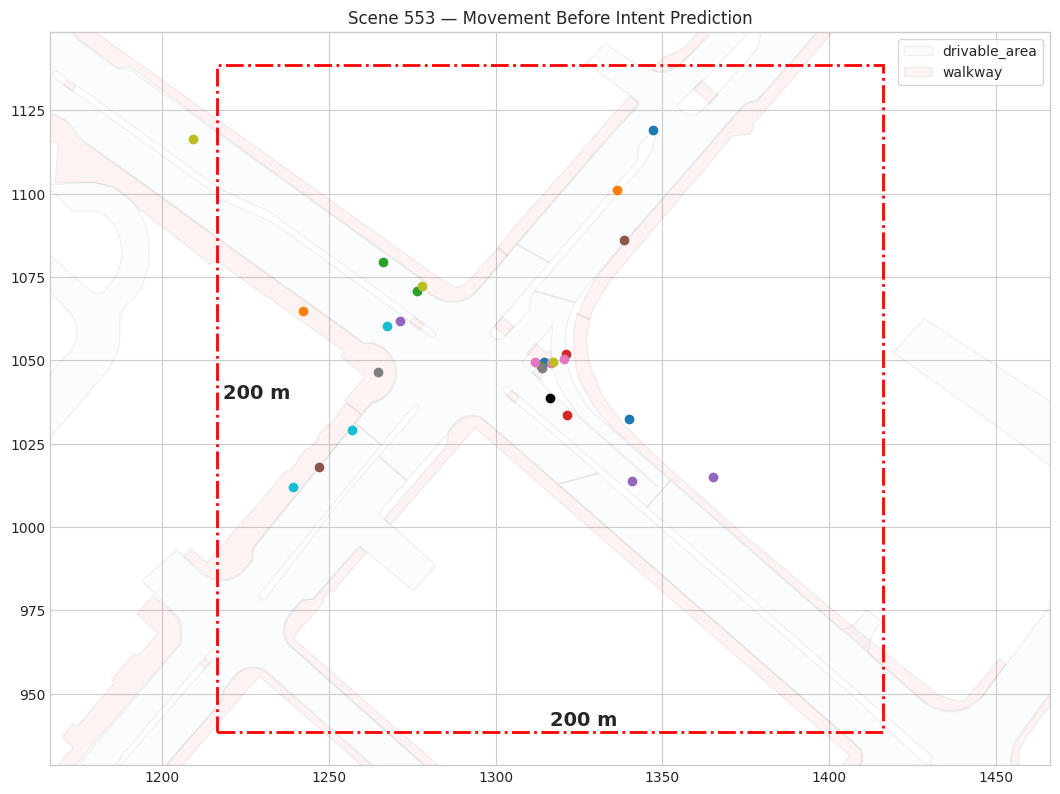

/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


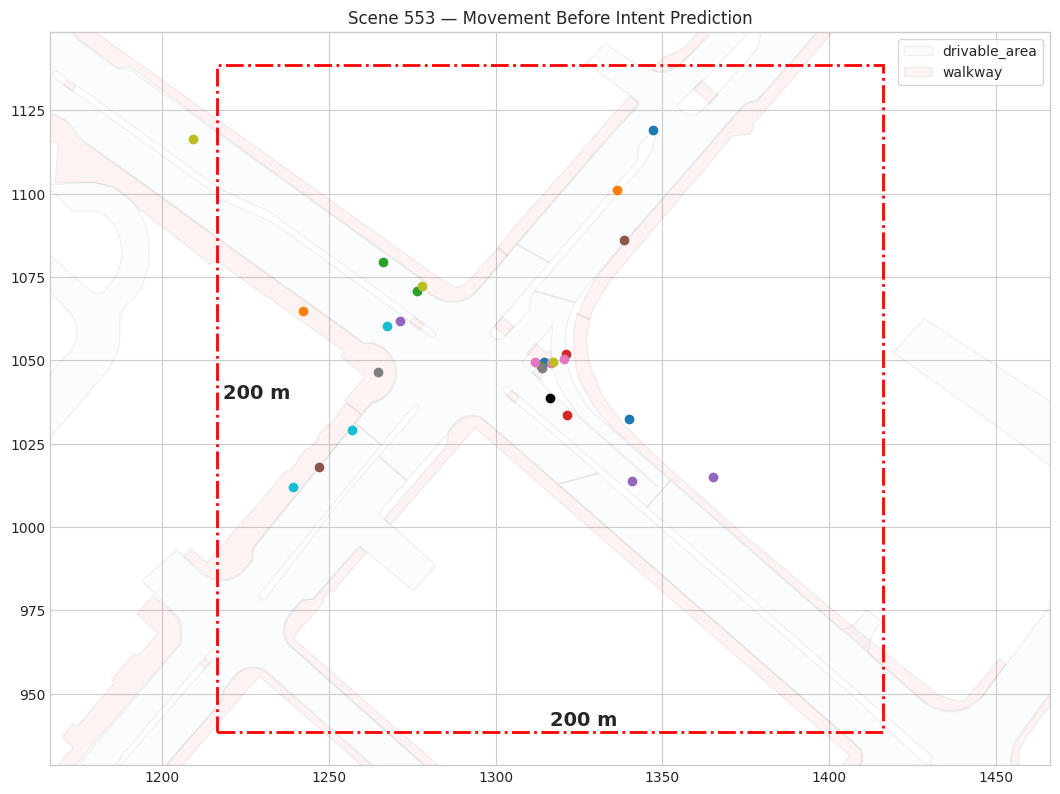

/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


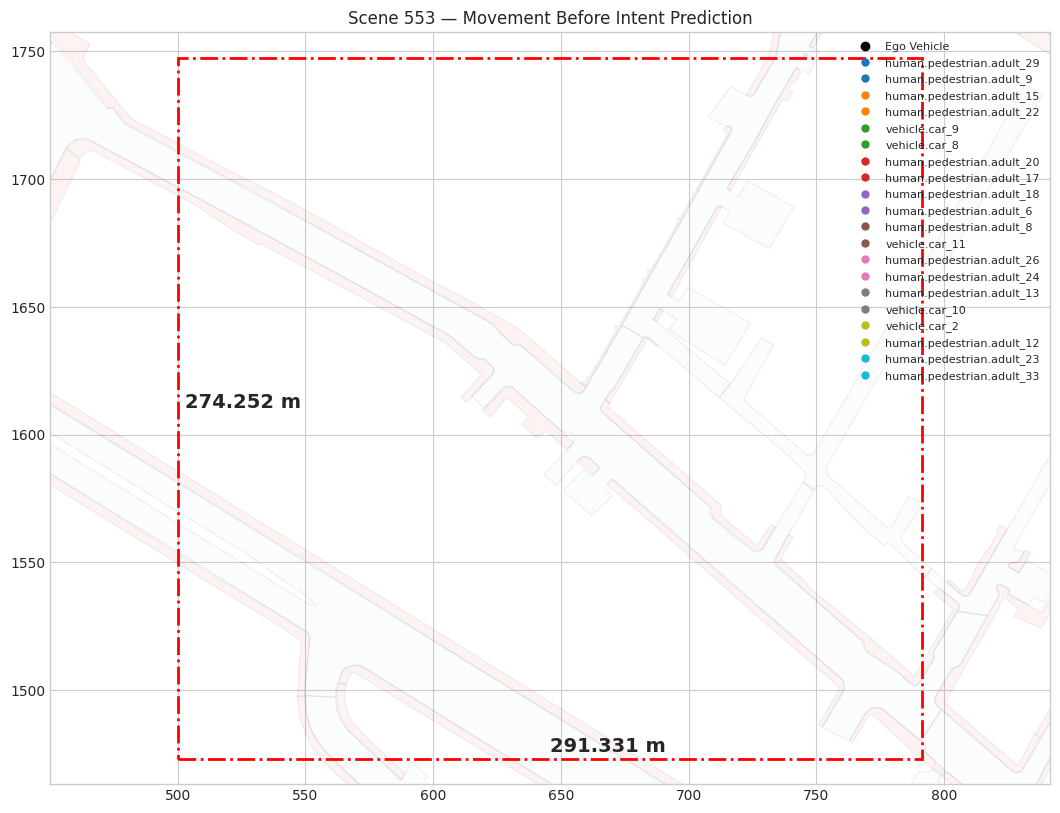

/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


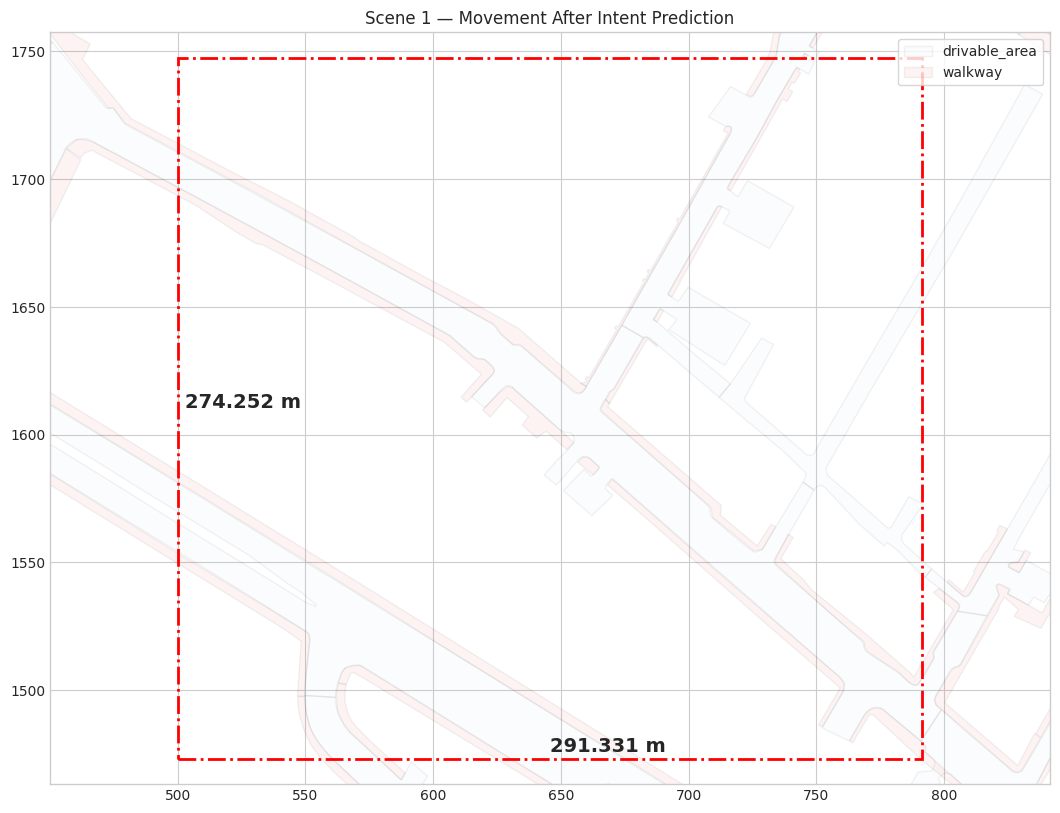

/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


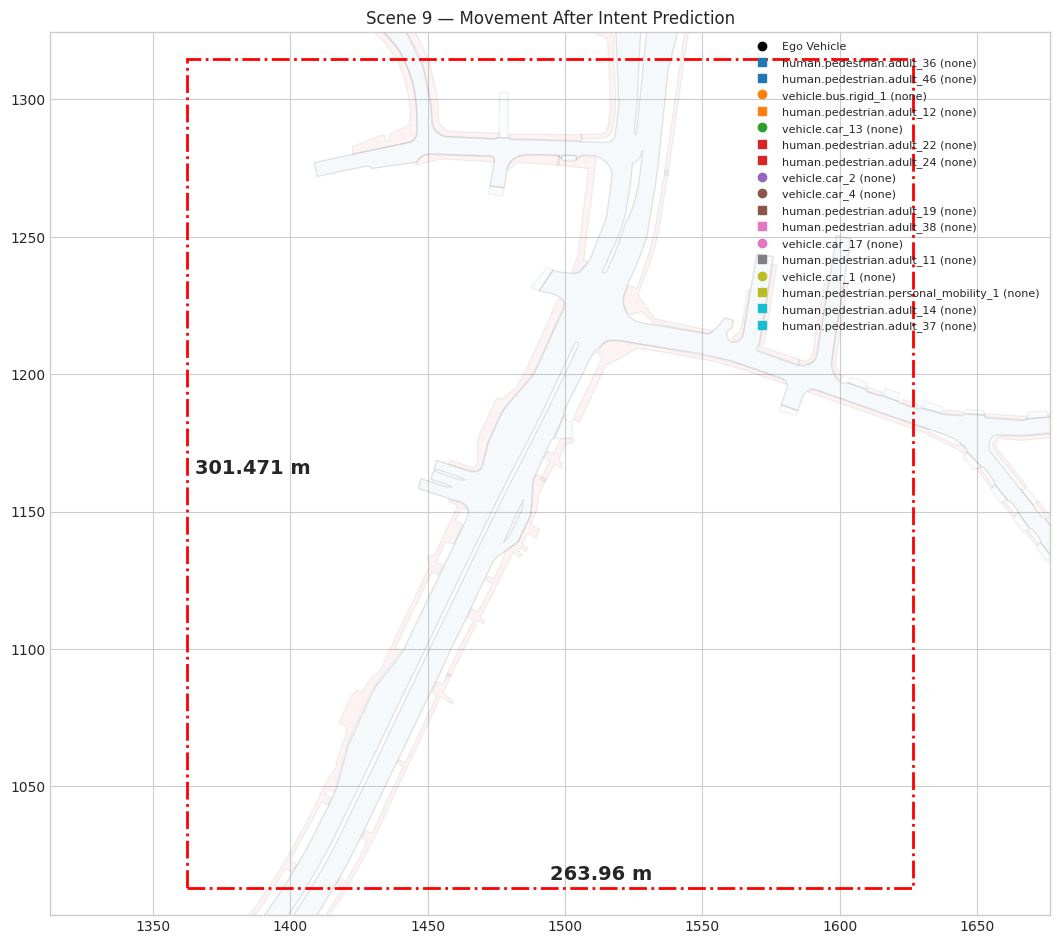

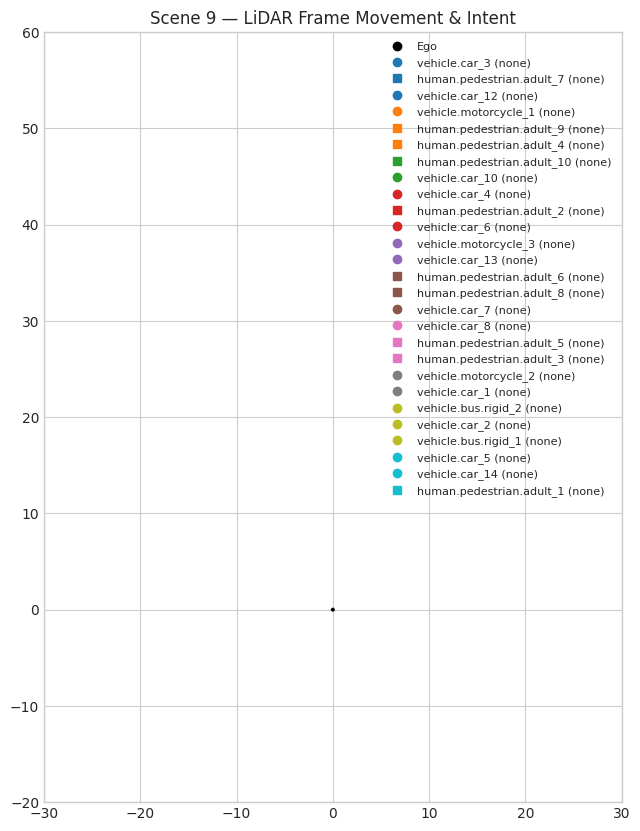

In [40]:
from matplotlib import pyplot as plt
from matplotlib import animation, cm
from collections import defaultdict
from pyquaternion import Quaternion
import numpy as np

scene_index = 9
scene = nusc.scene[scene_index]
first_sample_token = scene['first_sample_token']
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot=dataroot, map_name=location)

# Convert quaternion to yaw
def quaternion_to_yaw(q):
    q = Quaternion(q)
    return np.arctan2(2 * (q.w * q.z + q.x * q.y), 1 - 2 * (q.y**2 + q.z**2))

# Create dummy InstanceFrame to reuse Li's transformation logic
dummy_frame = InstanceFrame(
    nusc,
    list(predicted_intents.keys())[0],  # instance_token
    scene_index,
    {},  # dummy scene_ego_positions
    0    # dummy ego_vehicle_raw_start_time
)


# Store transformed LiDAR frame trajectories
timestamps = []
ego_orientations = []
ego_trajectory = []
object_trajectories = defaultdict(list)
object_orientations = defaultdict(list)
instance_timestamps_dict = defaultdict(list)
object_labels, object_category_root, object_name_counter = {}, {}, defaultdict(int)

sample_token = first_sample_token

while sample_token:
    sample = nusc.get('sample', sample_token)
    timestamps.append(sample['timestamp'])

    lidar_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
    ego_pose = nusc.get('ego_pose', lidar_data['ego_pose_token'])
    ego_pos = np.array(ego_pose['translation'])
    ego_rot = Quaternion(ego_pose['rotation'])
    ego_trajectory.append([0, 0])  # Ego is always at origin in LiDAR frame
    ego_orientations.append(0)     # Ego always faces +Y in LiDAR frame
    
    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        inst = ann['instance_token']
        category = ann['category_name']
        root = category.split('.')[0]
        object_category_root[inst] = root

        if inst not in object_labels:
            object_name_counter[category] += 1
            object_labels[inst] = f"{category}_{object_name_counter[category]}"

        obj_pos = np.array(ann['translation'])
        obj_rot = ann['rotation']
        pos_lidar, yaw = dummy_frame._transform_global_to_lidar(obj_pos, Quaternion(obj_rot), ego_pos, ego_rot)
        
        object_trajectories[inst].append(pos_lidar[:2])  # drop z-dimension if present
        object_orientations[inst].append(yaw)
        instance_timestamps_dict[inst].append(sample['timestamp'])
        if inst in selected_instances:
            print(f"{object_labels[inst]} @ {sample['timestamp']} → Pos: {pos_lidar[:2]}, Yaw(deg): {np.degrees(yaw):.2f}")


    sample_token = sample['next']

# Convert to NumPy
ego_trajectory = np.array(ego_trajectory)
timestamps = (np.array(timestamps) - min(timestamps)) / (max(timestamps) - min(timestamps))

# Filter top-10 movers
unique_location_counts = {k: len(set(map(tuple, object_trajectories[k]))) for k in object_trajectories}
sorted_lens = sorted(set(unique_location_counts.values()), reverse=True)
threshold = sorted_lens[9] if len(sorted_lens) > 10 else 0
selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold}

# Setup plot
color_map = cm.get_cmap("tab10", len(selected_instances))
instance_colors = {inst: color_map(i) for i, inst in enumerate(selected_instances)}
category_marker_map = {'vehicle': 'o', 'human': 's', 'movable_object': '^', 'animal': 'D', 'static_object': 'x', 'flat': 'P'}

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-30, 30)
ax.set_ylim(-20, 60)
ax.set_title("Scene 9 — LiDAR Frame Movement & Intent")
ax.set_aspect('equal')

ego_dot, = ax.plot([], [], 'ko', markersize=6, label='Ego')
ego_arrow = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1, color='black')

obj_dots, obj_texts = {}, {}
legend_handles = [ego_dot]

for inst in selected_instances:
    cat = object_category_root[inst]
    marker = category_marker_map.get(cat, 'o')
    color = instance_colors[inst]
    label = object_labels[inst]
    intent = predicted_intents.get(inst, "none")

    dot, = ax.plot([], [], marker=marker, linestyle='None', color=color, markersize=5)
    text = ax.text(0, 0, "", fontsize=7, color=color)
    obj_dots[inst], obj_texts[inst] = dot, text

    l_dot, = ax.plot([], [], marker=marker, linestyle='None', color=color, label=f"{label} ({intent})")
    legend_handles.append(l_dot)

ax.legend(handles=legend_handles, loc='upper right', fontsize=8)

def init():
    ego_dot.set_data([], [])
    ego_arrow.set_offsets([0, 0])
    ego_arrow.set_UVC(0, 0)
    for dot in obj_dots.values():
        dot.set_data([], [])
    for text in obj_texts.values():
        text.set_text("")
        text.set_position((0, 0))
    return [ego_dot, ego_arrow] + list(obj_dots.values()) + list(obj_texts.values())

def update(i):
    ego_dot.set_data(0, 0)
    global ego_arrow
    ego_arrow.remove()
    ego_arrow = ax.quiver(0, 0, 0, 3, angles='xy', scale_units='xy', scale=1, color='black')

    for inst in selected_instances:
        if i < len(object_trajectories[inst]):
            obj_x, obj_y = object_trajectories[inst][i]
            obj_dots[inst].set_data(obj_x, obj_y)
            obj_texts[inst].set_text(predicted_intents.get(inst, "none"))
            obj_texts[inst].set_position((obj_x + 1, obj_y + 1))

    return [ego_dot, ego_arrow] + list(obj_dots.values()) + list(obj_texts.values())

anim = animation.FuncAnimation(fig, update, init_func=init,
                               frames=len(ego_trajectory), interval=300, blit=False)

anim.save("scene9_after_intent_lidar.gif", writer="pillow", fps=5)


In [42]:
print(np.unique(ego_trajectory, axis=0).shape)


(40, 2)
